In [1]:
import os
import json
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # adjust slug if needed

TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"

VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"

TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"   # only annotations available for test

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
TARGET_RATIO = 0.6

random.seed(42)

# Count category frequencies
category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}


from concurrent.futures import ThreadPoolExecutor
print("Scanning dataset annotations...")

def process_annotation(args):

    IMAGE_DIR, ANN_DIR, ann_file = args

    if not ann_file.endswith(".json"):
        return None

    ann_path = os.path.join(ANN_DIR, ann_file)

    try:
        with open(ann_path) as f:
            data = json.load(f)
    except:
        return None

    if not isinstance(data, dict):
        return None

    cats = set()
    local_names = {}

    for key, val in data.items():

        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:

            cat = val["category_id"]
            cats.add(cat)

            if "category_name" in val:
                local_names[cat] = val["category_name"]

    if len(cats) == 0:
        return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))

    if not os.path.exists(image_path):
        return None

    return image_path, cats, local_names

tasks = []

for IMAGE_DIR, ANN_DIR in DATA_SPLITS:
    for ann_file in os.listdir(ANN_DIR):
        tasks.append((IMAGE_DIR, ANN_DIR, ann_file))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:

    if r is None:
        continue

    image_path, cats, local_names = r

    image_to_categories[image_path] = list(cats)

    for c in cats:
        category_counter[c] += 1

    category_id_to_name.update(local_names)


print("\nCategory frequencies:")
print(category_counter)

# Select top 5 categories
top5 = [c for c, _ in category_counter.most_common(5)]

print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

# Filter images containing top-5 classes
filtered_images = []

for img, cats in image_to_categories.items():

    filtered = [c for c in cats if c in top5]

    if len(filtered) > 0:
        filtered_images.append((img, filtered))


print("\nImages after filtering:", len(filtered_images))

# Create multi-label vectors
dataset = []

for img, cats in filtered_images:

    label_vector = [0] * NUM_CLASSES

    for c in cats:
        label_vector[label_map[c]] = 1

    dataset.append({
        "image": img,
        "labels": label_vector
    })


print("Dataset entries created:", len(dataset))

# Balanced subset sampling
target_size = int(len(dataset) * TARGET_RATIO)

print("\nCreating balanced subset:", target_size)

class_buckets = defaultdict(list)

for sample in dataset:

    for idx, val in enumerate(sample["labels"]):

        if val == 1:
            class_buckets[idx].append(sample)


subset = []
seen = set()

target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):

    candidates = class_buckets[cls]
    random.shuffle(candidates)

    selected = 0

    for sample in candidates:

        if sample["image"] in seen:
            continue

        subset.append(sample)
        seen.add(sample["image"])
        selected += 1

        if selected >= target_per_class:
            break

print("Subset size:", len(subset))

# Train / Validation / Test split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Save splits
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:

    imgs, lbls = splits[split]

    data = []

    for img, lbl in zip(imgs, lbls):

        data.append({
            "image": os.path.relpath(img, start=BASE),
            "labels": lbl
        })

    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{split} file saved → {out_path}")


print("\nPreprocessing completed successfully.")

# Save label_map so preprocessing_detection.py can read the exact same top-5
# Create required format: class_name -> index
# Required class order from assignment
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

print("\nFinal Label Mapping (class_name -> index):")
for name, idx in label_map_json.items():
    print(f"{name} : {idx}")

# Save label_map.json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("\nlabel_map.json saved in required format.")

Scanning dataset annotations...

Category frequencies:
Counter({1: 82957, 8: 64463, 2: 41667, 7: 40465, 9: 37124, 12: 21086, 10: 20104, 5: 18072, 4: 15380, 11: 9263, 13: 7592, 6: 2281, 3: 681})

Top 5 categories: [1, 8, 2, 7, 9]

Images after filtering: 167915
Dataset entries created: 167915

Creating balanced subset: 100749
Subset size: 100745

Split sizes:
Train: 70521
Validation: 15112
Test: 15112
train file saved → /kaggle/working/processed_dataset/train.json
val file saved → /kaggle/working/processed_dataset/val.json
test file saved → /kaggle/working/processed_dataset/test.json

Preprocessing completed successfully.

Final Label Mapping (class_name -> index):
short sleeve top : 0
trousers : 1
shorts : 2
long sleeve top : 3
skirt : 4

label_map.json saved in required format.


In [3]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # Adjust slug if needed
TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"
VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"
TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(42)

category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}

print("Scanning dataset annotations...")

def process_annotation(args):
    IMAGE_DIR, ANN_DIR, ann_file = args
    if not ann_file.endswith(".json"): return None
    ann_path = os.path.join(ANN_DIR, ann_file)
    try:
        with open(ann_path) as f: data = json.load(f)
    except: return None
    if not isinstance(data, dict): return None

    cats = set()
    local_names = {}
    for key, val in data.items():
        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:
            cat = val["category_id"]
            cats.add(cat)
            if "category_name" in val:
                local_names[cat] = val["category_name"]
    if len(cats) == 0: return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))
    if not os.path.exists(image_path): return None

    return image_path, cats, local_names

tasks = [(I, A, f) for I, A in DATA_SPLITS for f in os.listdir(A)]

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:
    if r is None: continue
    image_path, cats, local_names = r
    image_to_categories[image_path] = list(cats)
    for c in cats: category_counter[c] += 1
    category_id_to_name.update(local_names)

top5 = [c for c, _ in category_counter.most_common(5)]
print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

filtered_images = []
for img, cats in image_to_categories.items():
    filtered = [c for c in cats if c in top5]
    if len(filtered) > 0:
        filtered_images.append((img, filtered))

dataset = []
for img, cats in filtered_images:
    label_vector = [0] * NUM_CLASSES
    for c in cats: label_vector[label_map[c]] = 1
    dataset.append({"image": img, "labels": label_vector})

# ========================================================
# STRICT 25,000 IMAGE LIMIT APPLIED HERE
# ========================================================
target_size = 25000
print(f"\nCreating balanced subset of EXACTLY {target_size} images...")

class_buckets = defaultdict(list)
for sample in dataset:
    for idx, val in enumerate(sample["labels"]):
        if val == 1: class_buckets[idx].append(sample)

subset = []
seen = set()
target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):
    candidates = class_buckets[cls]
    random.shuffle(candidates)
    selected = 0
    for sample in candidates:
        if sample["image"] in seen: continue
        subset.append(sample)
        seen.add(sample["image"])
        selected += 1
        if selected >= target_per_class: break

print("Final Subset size:", len(subset))

# 70/15/15 Split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(images, labels, test_size=0.30, random_state=42)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(temp_imgs, temp_labels, test_size=0.5, random_state=42)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:
    imgs, lbls = splits[split]
    data = [{"image": os.path.relpath(img, start=BASE), "labels": lbl} for img, lbl in zip(imgs, lbls)]
    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")
    with open(out_path, "w") as f: json.dump(data, f, indent=2)

# Save standard label map
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("Base preprocessing complete. Master splits locked to 15k.")

Scanning dataset annotations...

Top 5 categories: [1, 8, 2, 7, 9]

Creating balanced subset of EXACTLY 25000 images...
Final Subset size: 25000
Base preprocessing complete. Master splits locked to 15k.


In [4]:
import os
import json
import shutil
import numpy as np
from PIL import Image, ImageDraw

CLASSIFICATION_OUTPUT_DIR = "/kaggle/working/processed_dataset"
OUTPUT_DIR = "/kaggle/working/processed_dataset"
BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"

ALL_ANN_DIRS = [f"{BASE}/train/annos", f"{BASE}/validation/annos", f"{BASE}/json_for_validation"]
ALL_IMAGE_DIRS = [f"{BASE}/train/image", f"{BASE}/validation/image", f"{BASE}/test/test"]

CATEGORY_NAMES = {
    1: "short_sleeve_top", 2: "long_sleeve_top", 3: "short_sleeve_outwear",
    4: "long_sleeve_outwear", 5: "vest", 6: "sling", 7: "shorts",
    8: "trousers", 9: "skirt", 10: "short_sleeve_dress",
    11: "long_sleeve_dress", 12: "vest_dress", 13: "sling_dress",
}

with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, "label_map.json")) as f:
    class_name_to_idx = json.load(f)

label_map = {}
top5 = []
for orig_id, name in CATEGORY_NAMES.items():
    readable_name = name.replace("_", " ")
    if readable_name in class_name_to_idx:
        label_map[orig_id] = class_name_to_idx[readable_name]
        top5.append(orig_id)

NUM_CLASSES = len(label_map)

split_map = {}
for split_name in ["train", "val", "test"]:
    with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, f"{split_name}.json")) as f:
        records = json.load(f)
    split_map[split_name] = [r["image"] for r in records]

stem_to_ann, stem_to_img = {}, {}
for ann_dir in ALL_ANN_DIRS:
    if not os.path.isdir(ann_dir): continue
    for ann_file in os.listdir(ann_dir):
        if ann_file.endswith(".json"): stem_to_ann[os.path.splitext(ann_file)[0]] = os.path.join(ann_dir, ann_file)

for img_dir in ALL_IMAGE_DIRS:
    if not os.path.isdir(img_dir): continue
    for img_file in os.listdir(img_dir):
        stem_to_img[os.path.splitext(img_file)[0]] = os.path.join(img_dir, img_file)

def stem_from_path(path): return os.path.splitext(os.path.basename(path))[0]
def get_image_size(img_path):
    try:
        with Image.open(img_path) as im: return im.width, im.height
    except: return 0, 0
def polygon_area(poly):
    n = len(poly) // 2
    if n < 3: return 0.0
    xs, ys = [poly[2 * i] for i in range(n)], [poly[2 * i + 1] for i in range(n)]
    area = sum(xs[i] * ys[(i + 1) % n] - xs[(i + 1) % n] * ys[i] for i in range(n))
    return abs(area) / 2.0

def parse_annotations(ann_path):
    with open(ann_path) as f: data = json.load(f)
    instances = []
    for key, item in data.items():
        if not key.startswith("item"): continue
        orig_cat = item.get("category_id")
        if orig_cat not in label_map or item.get("bounding_box") is None: continue
        instances.append({
            "category_id": label_map[orig_cat], "original_category_id": orig_cat,
            "bbox": item["bounding_box"], "segmentation": item.get("segmentation") or [],
        })
    return instances

def resolve(stored_path):
    stem = stem_from_path(stored_path)
    img_path = stored_path if os.path.exists(stored_path) else stem_to_img.get(stem)
    if stem_to_ann.get(stem) is None or img_path is None: return None
    return stem, stem_to_ann[stem], img_path

def save_detection_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_detection.json")
    records = []
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if resolved and (instances := parse_annotations(resolved[1])):
            records.append({"image": resolved[2], "annotations": instances})
    with open(out_path, "w") as f: json.dump(records, f, indent=2)

def save_coco_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_coco.json")
    categories = sorted([{"id": label_map[orig] + 1, "name": CATEGORY_NAMES.get(orig, str(orig))} for orig in top5], key=lambda x: x["id"])
    images_out, anns_out = [], []
    image_id, ann_id = 1, 1
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if not resolved or not (instances := parse_annotations(resolved[1])): continue
        w, h = get_image_size(resolved[2])
        images_out.append({"id": image_id, "file_name": resolved[2], "width": w, "height": h})
        for inst in instances:
            x1, y1, x2, y2 = inst["bbox"]
            area = sum(polygon_area(p) for p in inst["segmentation"]) or float((x2 - x1) * (y2 - y1))
            anns_out.append({"id": ann_id, "image_id": image_id, "category_id": inst["category_id"] + 1,
                             "bbox": [x1, y1, x2 - x1, y2 - y1], "area": area, "segmentation": inst["segmentation"], "iscrowd": 0})
            ann_id += 1
        image_id += 1
    with open(out_path, "w") as f: json.dump({"images": images_out, "annotations": anns_out, "categories": categories}, f, indent=2)

def save_yolo(split_map_local):
    yolo_root = os.path.join(OUTPUT_DIR, "yolo_dataset")
    for split_name, image_list in split_map_local.items():
        img_out, lbl_out = os.path.join(yolo_root, "images", split_name), os.path.join(yolo_root, "labels", split_name)
        os.makedirs(img_out, exist_ok=True); os.makedirs(lbl_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            dst_img = os.path.join(img_out, os.path.basename(resolved[2]))
            if not os.path.exists(dst_img): shutil.copy2(resolved[2], dst_img)
            lines = []
            for inst in instances:
                cls, (x1, y1, x2, y2) = inst["category_id"], inst["bbox"]
                lines.append(f"{cls} {((x1 + x2) / 2) / w:.6f} {((y1 + y2) / 2) / h:.6f} {(x2 - x1) / w:.6f} {(y2 - y1) / h:.6f}")
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: lines.append(f"{cls} " + " ".join([f"{poly[k]/w:.6f} {poly[k+1]/h:.6f}" for k in range(0, len(poly), 2)]))
            with open(os.path.join(lbl_out, resolved[0] + ".txt"), "w") as f: f.write("\n".join(lines))
    
    class_names = [None] * NUM_CLASSES
    for orig_id, idx in label_map.items(): class_names[idx] = CATEGORY_NAMES.get(orig_id, str(orig_id)).replace("_", " ")
    with open(os.path.join(yolo_root, "dataset.yaml"), "w") as f:
        f.write("\n".join([f"path: {os.path.abspath(yolo_root)}", "train: images/train", "val: images/val", "test: images/test", "", f"nc: {NUM_CLASSES}", f"names: {class_names}"]))

def save_unet_masks(split_map_local):
    mask_root = os.path.join(OUTPUT_DIR, "unet_masks")
    for split_name, image_list in split_map_local.items():
        mask_out = os.path.join(mask_root, split_name)
        os.makedirs(mask_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            pil_mask, draw = Image.fromarray(np.zeros((h, w), dtype=np.uint8)), ImageDraw.Draw(Image.fromarray(np.zeros((h, w), dtype=np.uint8)))
            for inst in instances:
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: draw.polygon([(poly[k], poly[k+1]) for k in range(0, len(poly), 2)], fill=inst["category_id"] + 1)
            draw._image.save(os.path.join(mask_out, resolved[0] + ".png"))

print("\n--- Generating Generic Detection JSONs ---")
for split_name, image_list in split_map.items(): save_detection_json(split_name, image_list)
print("\n--- Generating COCO JSONs (Mask R-CNN) ---")
for split_name, image_list in split_map.items(): save_coco_json(split_name, image_list)
print("\n--- Generating YOLO Dataset ---")
save_yolo(split_map)
print("\n--- Generating U-Net Semantic Masks ---")
save_unet_masks(split_map)

print("\n15k Formatting completely finished. You are ready to train.")


--- Generating Generic Detection JSONs ---

--- Generating COCO JSONs (Mask R-CNN) ---

--- Generating YOLO Dataset ---

--- Generating U-Net Semantic Masks ---

15k Formatting completely finished. You are ready to train.


In [5]:
# Install required libraries
!pip install segmentation-models-pytorch pycocotools scikit-learn matplotlib opencv-python

import os
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_curve, auc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Paths mapped directly from your new 15k preprocessing output
IMAGE_DIR = "/kaggle/working/processed_dataset/yolo_dataset/images/train"
MASK_DIR = "/kaggle/working/processed_dataset/unet_masks/train"
VAL_IMAGE_DIR = "/kaggle/working/processed_dataset/yolo_dataset/images/val"
VAL_MASK_DIR = "/kaggle/working/processed_dataset/unet_masks/val"
VAL_COCO_JSON = "/kaggle/working/processed_dataset/val_coco.json" 
OUTPUT_DIR = "/kaggle/working/model_files"

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 6 # 5 clothing classes + 1 background (0)

print("U-Net Setup Complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00
U-Net Setup Complete.


In [6]:
class UNetDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
        
        # Standardize inputs to 512x512 for memory efficiency
        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
        ])
        
        # NEAREST interpolation is critical so we don't blur class indices (0,1,2,3,4,5)
        self.mask_transform = transforms.Compose([
            transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.NEAREST),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        stem = os.path.splitext(img_name)[0]
        
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, stem + ".png")
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path) 
        
        image = self.transform(image)
        mask = self.mask_transform(mask)
        
        # Convert mask to long tensor for CrossEntropyLoss
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        
        return image, mask, stem

train_dataset = UNetDataset(IMAGE_DIR, MASK_DIR)
val_dataset = UNetDataset(VAL_IMAGE_DIR, VAL_MASK_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

Loaded 16638 training images and 3590 validation images.


In [7]:
print("--- STARTING U-NET TRAINING FROM SCRATCH ---")

# Initialize U-Net with ResNet34 backbone, NO pretrained weights
model_scratch = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights=None,     # Random initialization
    in_channels=3,                  
    classes=NUM_CLASSES,      # 6 classes (Background=0, Apparel=1-5)
)
model_scratch = model_scratch.to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model_scratch.train()
    total_loss = 0
    
    for images, masks, _ in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model_scratch(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"[Scratch] Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}")

scratch_path = os.path.join(OUTPUT_DIR, "unet_scratch.pth")
torch.save(model_scratch.state_dict(), scratch_path)
print(f"Saved scratch model to {scratch_path}")

--- STARTING U-NET TRAINING FROM SCRATCH ---
[Scratch] Epoch 1/10 - Loss: 0.7608
[Scratch] Epoch 2/10 - Loss: 0.5354
[Scratch] Epoch 3/10 - Loss: 0.4701
[Scratch] Epoch 4/10 - Loss: 0.4292
[Scratch] Epoch 5/10 - Loss: 0.3928
[Scratch] Epoch 6/10 - Loss: 0.3622
[Scratch] Epoch 7/10 - Loss: 0.3350
[Scratch] Epoch 8/10 - Loss: 0.3097
[Scratch] Epoch 9/10 - Loss: 0.2866
[Scratch] Epoch 10/10 - Loss: 0.2648
Saved scratch model to /kaggle/working/model_files/unet_scratch.pth


In [8]:
print("--- STARTING U-NET TRANSFER LEARNING ---")

# Initialize U-Net WITH pretrained ImageNet weights
model_transfer = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet", # Transfer learning
    in_channels=3,                  
    classes=NUM_CLASSES,                      
)

# Freeze the encoder layers (Backbone)
for param in model_transfer.encoder.parameters():
    param.requires_grad = False

model_transfer = model_transfer.to(DEVICE)

# Only optimize the decoder and segmentation head
optimizer = torch.optim.Adam([
    {'params': model_transfer.decoder.parameters()},
    {'params': model_transfer.segmentation_head.parameters()},
], lr=1e-4)

for epoch in range(EPOCHS):
    model_transfer.train()
    total_loss = 0
    
    for images, masks, _ in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model_transfer(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"[Transfer] Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}")

transfer_path = os.path.join(OUTPUT_DIR, "unet_transfer.pth")
torch.save(model_transfer.state_dict(), transfer_path)
print(f"Saved transfer model to {transfer_path}")

--- STARTING U-NET TRANSFER LEARNING ---


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[Transfer] Epoch 1/10 - Loss: 0.5650
[Transfer] Epoch 2/10 - Loss: 0.4181
[Transfer] Epoch 3/10 - Loss: 0.3844
[Transfer] Epoch 4/10 - Loss: 0.3653
[Transfer] Epoch 5/10 - Loss: 0.3488
[Transfer] Epoch 6/10 - Loss: 0.3368
[Transfer] Epoch 7/10 - Loss: 0.3259
[Transfer] Epoch 8/10 - Loss: 0.3172
[Transfer] Epoch 9/10 - Loss: 0.3069
[Transfer] Epoch 10/10 - Loss: 0.2993
Saved transfer model to /kaggle/working/model_files/unet_transfer.pth



     SCRATCH U-NET RESULTS
loading annotations into memory...
Done (t=0.20s)
creating index...
index created!

🔹 Detection F1 Scores:
Class 0: Precision=0.464, Recall=0.420, F1=0.441
Class 1: Precision=0.563, Recall=0.372, F1=0.448
Class 2: Precision=0.651, Recall=0.251, F1=0.363
Class 3: Precision=0.390, Recall=0.388, F1=0.389
Class 4: Precision=0.398, Recall=0.375, F1=0.386

Macro F1: 0.405
Micro F1: 0.413

🔹 Segmentation Metrics:
Class 0: IoU=0.560, Dice=0.681
Class 1: IoU=0.606, Dice=0.725
Class 2: IoU=0.718, Dice=0.819
Class 3: IoU=0.594, Dice=0.718
Class 4: IoU=0.618, Dice=0.738

Overall mIoU: 0.619
Overall Dice: 0.736

🔹 ROC Curves:


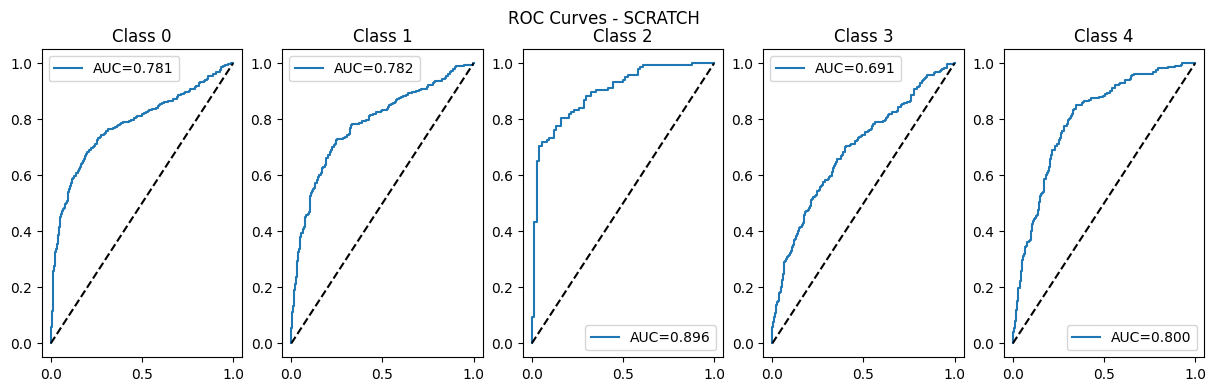


🔹 COCO mAP:
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.79s).
Accumulating evaluation results...
DONE (t=0.18s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.120
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.284
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.086
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.127
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.169
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.171
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.171
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= smal

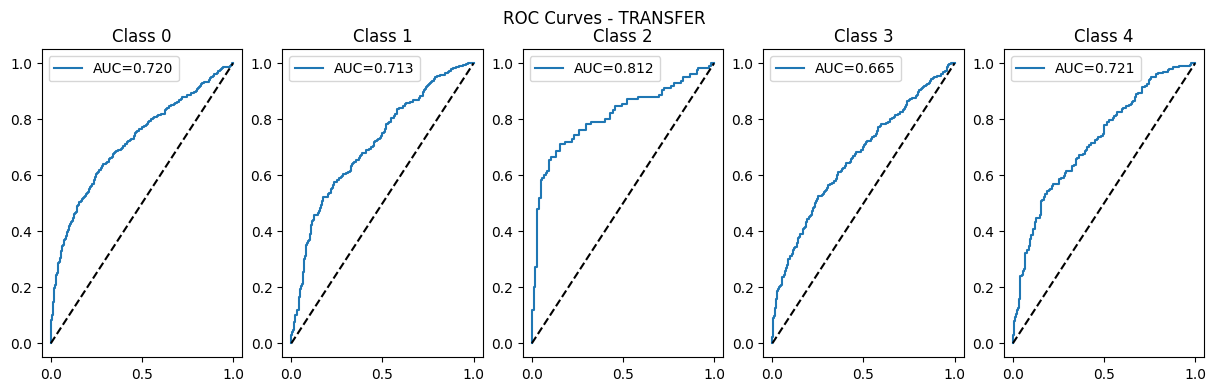


🔹 COCO mAP:
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.59s).
Accumulating evaluation results...
DONE (t=0.19s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.246
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.116
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.167
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.172
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.172
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= smal

In [9]:
def extract_instances_majority_voting(semantic_mask, prob_map, original_w, original_h):
    """
    Applies Connected Component Analysis, Bbox extraction, Majority Voting, 
    and assigns a confidence score based on pixel probabilities.
    """
    instances = []
    semantic_mask = cv2.resize(semantic_mask.astype(np.uint8), (original_w, original_h), interpolation=cv2.INTER_NEAREST)
    
    # Resize probability map to match original image dimensions
    # prob_map shape is (NUM_CLASSES, H, W). We resize the H, W dimensions.
    prob_map_resized = np.zeros((NUM_CLASSES, original_h, original_w), dtype=np.float32)
    for c in range(NUM_CLASSES):
        prob_map_resized[c] = cv2.resize(prob_map[c], (original_w, original_h), interpolation=cv2.INTER_LINEAR)
    
    # 1. Isolate the foreground (any class > 0)
    foreground = (semantic_mask > 0).astype(np.uint8)
    
    if foreground.sum() == 0:
        return instances
        
    # 2. Connected Component Analysis
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(foreground, connectivity=8)
    
    # Start from 1 to ignore background component (0)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 200: # Filter out tiny noise artifacts
            continue
            
        # 3. Extract Bounding Box
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        
        # Isolate this specific instance's mask
        instance_mask = (labels == i)
        
        # 4. Majority Voting
        classes_in_component = semantic_mask[instance_mask]
        majority_class = np.bincount(classes_in_component).argmax()
        
        if majority_class == 0:
            continue
            
        # 5. Extract Confidence Score (Mean probability of the majority class in this mask)
        confidence_score = prob_map_resized[majority_class][instance_mask].mean()
            
        instances.append({
            "category_id": int(majority_class),
            "bbox": [x, y, w, h], 
            "mask": instance_mask.astype(np.uint8),
            "score": float(confidence_score) 
        })
            
    return instances

def evaluate_unet(model_path, name, num_eval_images=2000):
    print(f"\n==============================")
    print(f"     {name} U-NET RESULTS")
    print(f"==============================")
    
    # Load model
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=NUM_CLASSES)
    model.load_state_dict(torch.load(model_path))
    model = model.to(DEVICE)
    model.eval()
    
    coco_gt = COCO(VAL_COCO_JSON)
    img_ids = coco_gt.getImgIds()
    eval_ids = img_ids[:num_eval_images]
    
    results_for_map = []
    ious = [[] for _ in range(5)]
    dices = [[] for _ in range(5)]
    tp, fp, fn = [0]*5, [0]*5, [0]*5
    
    # For ROC/AUC
    scores_pc = [[] for _ in range(5)]
    labels_pc = [[] for _ in range(5)]
    
    with torch.no_grad():
        for img_id in eval_ids:
            img_info = coco_gt.loadImgs(img_id)[0]
            img_path = os.path.join(VAL_IMAGE_DIR, img_info['file_name'].split('/')[-1])
            
            if not os.path.exists(img_path):
                continue
            
            # Ground Truth
            ann_ids = coco_gt.getAnnIds(imgIds=img_id)
            anns = coco_gt.loadAnns(ann_ids)
            gt_labels = [a['category_id'] - 1 for a in anns] 
            gt_boxes = [[a['bbox'][0], a['bbox'][1], a['bbox'][0]+a['bbox'][2], a['bbox'][1]+a['bbox'][3]] for a in anns]
            
            # Inference
            image = Image.open(img_path).convert("RGB")
            input_tensor = transforms.Compose([
                transforms.Resize((512, 512)),
                transforms.ToTensor(),
            ])(image).unsqueeze(0).to(DEVICE)
            
            logits = model(input_tensor)
            
            # Get Probabilities via Softmax (For Confidence Scores)
            prob_map = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
            # Get Class Predictions via Argmax
            semantic_pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
            
            # Post-processing (Now passing the prob_map to get dynamic scores)
            instances = extract_instances_majority_voting(semantic_pred, prob_map, img_info['width'], img_info['height'])
            
            # Format for mAP
            for inst in instances:
                results_for_map.append({
                    "image_id": img_id,
                    "category_id": inst["category_id"],
                    "bbox": inst["bbox"],
                    "score": inst["score"]
                })
                
            # Formatting for F1, ROC, AUC matching
            pred_boxes = [[i["bbox"][0], i["bbox"][1], i["bbox"][0]+i["bbox"][2], i["bbox"][1]+i["bbox"][3]] for i in instances]
            pred_labels = [i["category_id"] - 1 for i in instances]
            pred_scores = [i["score"] for i in instances]
            
            matched = set()
            for i, (pb, pl, sc) in enumerate(zip(pred_boxes, pred_labels, pred_scores)):
                best_iou, best_idx = 0, -1
                for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    xa, ya = max(pb[0], gb[0]), max(pb[1], gb[1])
                    xb, yb = min(pb[2], gb[2]), min(pb[3], gb[3])
                    inter = max(0, xb-xa) * max(0, yb-ya)
                    union = (pb[2]-pb[0])*(pb[3]-pb[1]) + (gb[2]-gb[0])*(gb[3]-gb[1]) - inter
                    iou_val = inter / union if union > 0 else 0
                    
                    if iou_val > best_iou:
                        best_iou, best_idx = iou_val, j
                        
                if best_iou >= 0.5:
                    if pl == gt_labels[best_idx]:
                        tp[pl] += 1
                        matched.add(best_idx)
                        labels_pc[pl].append(1) # True Positive for ROC
                    else:
                        fp[pl] += 1
                        labels_pc[pl].append(0) # False Positive for ROC
                else:
                    fp[pl] += 1
                    labels_pc[pl].append(0)
                
                scores_pc[pl].append(sc)
                    
            for j, gl in enumerate(gt_labels):
                if j not in matched:
                    fn[gl] += 1
                    
            # Semantic Segmentation Metrics (mIoU and Dice)
            for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                gt_mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
                for seg in anns[j]["segmentation"]:
                    poly = np.array(seg).reshape(-1, 2)
                    cv2.fillPoly(gt_mask, [poly.astype(np.int32)], 1)
                    
                best_inter, best_pm = 0, None
                if len(instances) > 0:
                    for inst in instances:
                        if (inst["category_id"] - 1) == gl:
                            pm = inst["mask"]
                            inter = (pm & gt_mask).sum()
                            if inter > best_inter:
                                best_inter, best_pm = inter, pm
                                
                if best_pm is not None:
                    union = (best_pm | gt_mask).sum()
                    if union > 0:
                        ious[gl].append(best_inter / union)
                        dices[gl].append(2 * best_inter / (best_pm.sum() + gt_mask.sum() + 1e-6))

    # --- Print Metrics ---
    print("\n🔹 Detection F1 Scores:")
    f1_list = []
    for i in range(5):
        p = tp[i] / (tp[i] + fp[i] + 1e-6)
        r = tp[i] / (tp[i] + fn[i] + 1e-6)
        f = 2 * p * r / (p + r + 1e-6)
        f1_list.append(f)
        print(f"Class {i}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

    # Micro and Macro F1
    total_tp, total_fp, total_fn = sum(tp), sum(fp), sum(fn)
    micro_f1 = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-6)
    macro_f1 = np.mean(f1_list)
    print(f"\nMacro F1: {macro_f1:.3f}")
    print(f"Micro F1: {micro_f1:.3f}")

    print("\n🔹 Segmentation Metrics:")
    for i in range(5):
        if ious[i]:
            print(f"Class {i}: IoU={np.mean(ious[i]):.3f}, Dice={np.mean(dices[i]):.3f}")
            
    print(f"\nOverall mIoU: {np.mean([np.mean(x) for x in ious if x]):.3f}")
    print(f"Overall Dice: {np.mean([np.mean(x) for x in dices if x]):.3f}")

    # --- ROC Curves ---
    print("\n🔹 ROC Curves:")
    plt.figure(figsize=(15,4))
    for i in range(5):
        if len(set(labels_pc[i])) > 1:
            fpr, tpr, _ = roc_curve(labels_pc[i], scores_pc[i])
            roc_auc = auc(fpr, tpr)
            plt.subplot(1,5,i+1)
            plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
            plt.plot([0,1], [0,1], 'k--')
            plt.title(f"Class {i}")
            plt.legend()
    plt.suptitle(f"ROC Curves - {name}")
    plt.show()

    # COCO mAP
    print("\n🔹 COCO mAP:")
    if len(results_for_map) > 0:
        coco_dt = coco_gt.loadRes(results_for_map)
        coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
        coco_eval.params.imgIds = eval_ids
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
    else:
        print("No valid detections made to calculate mAP.")

# Run Evaluation
evaluate_unet(scratch_path, "SCRATCH")
evaluate_unet(transfer_path, "TRANSFER")